# Assessing context duplication in QuAnTS

The *context* of a QuAnTS sample is the multivariate trajectory a question is asked about: the
`trajectory` column of the published dataset, shape `(320, 24, 3)` — 16 s at 20 FPS, 24 SMPL joints,
xyz. Length and channel count are constant across the dataset.

This notebook measures how much of that is redundant, at two levels:

1. **Signal level** — how many trajectories are near-duplicates of another trajectory, using a
   scale-free per-channel distance evaluated on every pair in the dataset, and a single-linkage
   threshold sweep validated against a phase-randomised surrogate.
2. **Label level** — how many samples share an identical 4-action sequence, and how many of those
   collisions cross the train/val/test boundary.

## Scope and limitations

**Raw world frame, as-is.** Global translation and heading are *not* removed. Two identical motions
performed at different places or facing different directions count as *different*. Every redundancy
number below is therefore a **lower bound** on motion-pattern redundancy — canonicalising root
position and yaw would only ever merge more samples, never fewer.

**Exhaustive, not candidate-based.** Every one of the $\binom{n}{2}$ pairs is scored, so no duplicate
can hide outside a neighbour list and the figures are exact rather than lower bounds. An earlier
version generated candidates from a k-nearest-neighbour search in an embedding; measured against a
full scan it recovered only ~77 % of the pairs below the permissive threshold, because it ranked by
embedding distance while the threshold applies to a different score. Only pairs at or below
`scan_cutoff` are retained, which is above the percolation onset and so discards nothing that is
interpreted.

**Single linkage.** The sweep merges transitively, so above the percolation point the clusters are
chaining artefacts rather than duplicate groups. That region is shaded in the figure and excluded
from interpretation.

## Setup

In [1]:
import hashlib
import re
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import DatasetDict, VerificationMode, load_dataset
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree
from tqdm.auto import tqdm

from generate.prompts.base import utility
from generate.prompts.base.utility import read_inputs

sns.set_context("talk")
sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")

CONFIG = {
    "scan_cutoff": 3.5,
    "scan_block": 256,
    "scan_channels": 8,
    "score_quantile": 0.95,
    "seed": 0,
    "n_null_pairs": 100_000,
    "degenerate_std": 1e-6,
    "score_batch": 512,
    "percolation_fraction": 0.10,
    "weight_floor": 1e-12,
    "duplicate_sigma": 0.5,
}
rng = np.random.default_rng(CONFIG["seed"])

if not torch.cuda.is_available():
    raise RuntimeError("This notebook requires a CUDA GPU.")
device = torch.device("cuda")
print(f"Using {torch.cuda.get_device_name(0)}")
CONFIG

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using Tesla V100-SXM3-32GB-H


{'scan_cutoff': 3.5,
 'scan_block': 256,
 'scan_channels': 8,
 'score_quantile': 0.95,
 'seed': 0,
 'n_null_pairs': 100000,
 'degenerate_std': 1e-06,
 'score_batch': 512,
 'percolation_fraction': 0.1,
 'weight_floor': 1e-12,
 'duplicate_sigma': 0.5}

## Loading the contexts

The contexts come from the published dataset on HuggingFace, loaded exactly the way
[dataset-statistics.ipynb](dataset-statistics.ipynb) loads it — except that `trajectory` is the one
column we need, so it is *not* dropped. The first run downloads ~14 GB and caches it; later runs are
fast.

Two things have to be handled that the statistics notebook does not care about:

- **Rows are per question, not per sample.** The same trajectory is repeated once for every QA pair
  it belongs to, and across the three answer-type variants. Contexts are therefore deduplicated by
  `sample_id`, keeping the first occurrence.
- **The split comes from the dataset itself.** `train`/`val`/`test` membership is read off the
  HuggingFace splits, so the leakage analysis needs nothing outside this notebook.

The parquet files are already cached locally by `datasets`, and rebuilding the deduplicated array from
them takes ~20 s, so there is nothing to gain from also caching the 2.8 GB of trajectories ourselves.
The pair scores further down *are* persisted — those cost real compute.

In [2]:
HF_REPO = "dasyd/quants"
VARIANTS = ["binary", "multi", "open"]
SPLITS = ["train", "val", "test"]

out_dir = Path("similarity").absolute()
out_dir.mkdir(exist_ok=True)
out_dir

PosixPath('/workspaces/quants-generate/quants/notebooks/similarity')

In [3]:
def load_contexts():
    "One trajectory per sample_id, plus its action sequence and split."
    variants = DatasetDict({
        variant: load_dataset(
            HF_REPO,
            variant,
            data_dir=variant,
            data_files={split: f"{split}-*" for split in SPLITS},
            verification_mode=VerificationMode.NO_CHECKS,
        )
        for variant in VARIANTS
    })

    # Project away `trajectory` first: arrow is columnar, so deciding which rows are duplicates
    # never touches the 14 GB of trajectories. Action sequences are converted one row at a time,
    # only for the rows actually kept.
    first_occurrence, splits, sequences = {}, {}, {}
    for variant, per_split in variants.items():
        for split, subset in per_split.items():
            light = subset.select_columns(["sample_id", "action_sequence"])
            sample_ids = light.data.column("sample_id").to_pylist()
            actions = light.data.column("action_sequence")
            for position, sample_id in enumerate(sample_ids):
                key = int(sample_id)
                if key not in first_occurrence:
                    first_occurrence[key] = (variant, split, position)
                    splits[key] = split
                    # `action_sequence` is declared Sequence(Features(...)), which arrow stores as
                    # a struct of lists rather than a list of per-step dicts, so the ordered action
                    # names are one field rather than a value per step.
                    sequences[key] = tuple(actions[position].as_py()["action"])

    ordered = sorted(first_occurrence)
    position_of = {key: index for index, key in enumerate(ordered)}
    trajectories = np.empty((len(ordered), 320, 24, 3), dtype=np.float32)

    grouped = defaultdict(list)
    for key, (variant, split, position) in first_occurrence.items():
        grouped[(variant, split)].append((position, position_of[key]))

    for (variant, split), items in tqdm(sorted(grouped.items()), desc="gathering trajectories"):
        items.sort()
        rows = [row for row, _ in items]
        targets = np.array([target for _, target in items])
        selected = variants[variant][split].select(rows).with_format("numpy")
        for start in range(0, len(rows), 512):
            block = selected[start:start + 512]["trajectory"]
            trajectories[targets[start:start + 512]] = block

    return (
        trajectories,
        np.array(ordered),
        [sequences[key] for key in ordered],
        np.array([splits[key] for key in ordered]),
    )

In [4]:
joints, ids, action_sequences, split_of = load_contexts()

print(f"{len(joints)} contexts from {HF_REPO}")
print({split: int((split_of == split).sum()) for split in SPLITS})
joints.shape, joints.dtype, f"{joints.nbytes / 1e9:.2f} GB"

gathering trajectories:   0%|          | 0/9 [00:00<?, ?it/s]

gathering trajectories:  11%|█         | 1/9 [00:01<00:10,  1.33s/it]

gathering trajectories:  22%|██▏       | 2/9 [00:12<00:50,  7.28s/it]

gathering trajectories:  33%|███▎      | 3/9 [00:14<00:27,  4.60s/it]

gathering trajectories:  44%|████▍     | 4/9 [00:14<00:14,  2.83s/it]

gathering trajectories:  56%|█████▌    | 5/9 [00:15<00:08,  2.17s/it]

gathering trajectories:  67%|██████▋   | 6/9 [00:15<00:04,  1.47s/it]

gathering trajectories: 100%|██████████| 9/9 [00:15<00:00,  1.72s/it]

30000 contexts from dasyd/quants
{'train': 24000, 'val': 3000, 'test': 3000}


((30000, 320, 24, 3), dtype('float32'), '2.76 GB')

## Data contract

Everything downstream assumes a constant shape and finite values. Assert it rather than discover it
later as a silently wrong number.

In [5]:
assert joints.ndim == 4 and joints.shape[1:] == (320, 24, 3), joints.shape
assert joints.dtype == np.float32, joints.dtype
assert np.isfinite(joints).all(), "non-finite values in joints"
assert len(action_sequences) == len(joints) == len(ids) == len(split_of)
assert len(set(ids.tolist())) == len(ids), "sample ids are not unique after deduplication"
assert set(split_of) <= set(SPLITS), set(split_of)

# (n, time, channel) with 24 joints x 3 axes flattened into 72 channels
series = np.ascontiguousarray(joints.reshape(len(joints), 320, 72))
n_total, n_time, n_channels = series.shape
del joints

n_total, n_time, n_channels

(30000, 320, 72)

## Degenerate series

A series whose every channel is constant has no scale, so the pooled per-channel denominator of the
pair metric collapses and every distance involving it becomes meaningless. This is the one failure
mode that would corrupt every downstream number, so it is checked explicitly and reported even when
the count is zero.

In [6]:
channel_std = series.std(axis=1)  # (n, 72)
degenerate_mask = (channel_std < CONFIG["degenerate_std"]).all(axis=1)
n_degenerate = int(degenerate_mask.sum())

any_degenerate = int((channel_std < CONFIG["degenerate_std"]).any(axis=1).sum())
print(f"Fully degenerate series (all 72 channels std < {CONFIG['degenerate_std']:g}): {n_degenerate}")
print(f"Series with at least one degenerate channel: {any_degenerate}")
print(f"Smallest per-series maximum channel std: {channel_std.max(axis=1).min():.6f}")

keep = ~degenerate_mask
series = np.ascontiguousarray(series[keep])
ids = ids[keep]
split_of = split_of[keep]
action_sequences = [seq for seq, k in zip(action_sequences, keep) if k]
n = len(series)
print(f"\nAnalysing n = {n} series ({n_degenerate} excluded).")

Fully degenerate series (all 72 channels std < 1e-06): 0
Series with at least one degenerate channel: 0
Smallest per-series maximum channel std: 0.041695



Analysing n = 30000 series (0 excluded).


## Exact duplicates

A cheap first pass before any metric is involved: group bit-identical arrays, and separately group
arrays that agree to 4 decimals. `sha256` is used only to bucket identical byte strings — no
cryptographic property is needed, and every hit is re-verified against the refined distance further
down.

In [7]:
def hash_groups(arrays, decimals=None):
    "Map each digest to the list of row indices producing it."
    groups = defaultdict(list)
    for index, array in enumerate(arrays):
        payload = array if decimals is None else np.round(array, decimals)
        digest = hashlib.sha256(np.ascontiguousarray(payload, np.float32).tobytes()).digest()
        groups[digest].append(index)
    return {digest: rows for digest, rows in groups.items() if len(rows) > 1}


exact_groups = {
    "raw": hash_groups(series),
    "round(4)": hash_groups(series, decimals=4),
}

for mode, groups in exact_groups.items():
    involved = sum(len(rows) for rows in groups.values())
    largest = max((len(rows) for rows in groups.values()), default=0)
    print(f"{mode:>9}: {len(groups)} duplicate groups, {involved} series involved, largest group {largest}")

exact_pairs_raw = {
    tuple(sorted(pair))
    for rows in exact_groups["raw"].values()
    for pair in combinations(rows, 2)
}
len(exact_pairs_raw)

      raw: 0 duplicate groups, 0 series involved, largest group 0
 round(4): 0 duplicate groups, 0 series involved, largest group 0


0

## The pair metric

For two series $x, y$ of shape (time, channel):

1. pooled per-channel scale $s_c = \sqrt{(\mathrm{var}(x_c) + \mathrm{var}(y_c)) / 2}$,
2. scaled absolute deviation $|x_{tc} - y_{tc}| / s_c$,
3. the 0.95-quantile over time, per channel,
4. the maximum over channels.

The result is in units of $\sigma$ and is symmetric in $x$ and $y$ — required, since it becomes an
undirected edge weight. Taking a high quantile rather than the maximum over time keeps a handful of
frames of disagreement from vetoing an otherwise identical pair; taking the maximum over channels
means *every* channel must agree for a pair to score low.

There is exactly **one** reduction over channels, the final maximum in step 4. The `SCALE_FLOOR`
applied to $s_c$ in step 1 is an element-wise floor on each channel's own scale — it guards the
division for a channel in which both series are near-constant, and does not combine channels.

A readable numpy version defines the metric; a batched torch version computes it 600 000 times.

In [8]:
# Smallest pooled per-channel scale we are willing to divide by. This is an element-wise floor on
# each channel's scale, NOT a reduction across channels: it only stops a channel whose pooled
# standard deviation is ~0 (both series near-constant in it) from blowing up the ratio. The single
# reduction over channels is the max on the last line of each function below.
SCALE_FLOOR = 1e-8


def pair_score(x, y, q=CONFIG["score_quantile"]):
    "Reference implementation, in units of sigma. x, y: (time, channel)."
    s = np.sqrt((x.var(axis=0, ddof=1) + y.var(axis=0, ddof=1)) / 2)  # (channel,)
    deviation = np.abs(x - y) / np.clip(s, SCALE_FLOOR, None)  # (time, channel)
    per_channel = np.quantile(deviation, q, axis=0)  # quantile over time -> (channel,)
    return float(per_channel.max())  # worst channel


def pair_score_batch(a, b, q=CONFIG["score_quantile"]):
    "Vectorised equivalent. a, b: (batch, time, channel) tensors on the same device."
    s = torch.sqrt((a.var(dim=1, unbiased=True) + b.var(dim=1, unbiased=True)) / 2)  # (batch, channel)
    deviation = (a - b).abs() / s.clamp_min(SCALE_FLOOR)[:, None, :]
    per_channel = torch.quantile(deviation, q, dim=1)  # quantile over time -> (batch, channel)
    return per_channel.amax(dim=1)  # worst channel

In [9]:
# Verification: the metric is symmetric, and the two implementations agree.
check_i = rng.integers(0, n, 100)
check_j = rng.integers(0, n, 100)
forward = np.array([pair_score(series[i], series[j]) for i, j in zip(check_i, check_j)])
backward = np.array([pair_score(series[j], series[i]) for i, j in zip(check_i, check_j)])
assert np.allclose(forward, backward, atol=1e-6), "pair_score is not symmetric"

batched = pair_score_batch(
    torch.from_numpy(series[check_i]), torch.from_numpy(series[check_j])
).numpy()
largest_gap = np.abs(forward - batched).max()
assert np.allclose(forward, batched, atol=1e-4), largest_gap
print(f"Symmetric and consistent on 100 random pairs (max |numpy - torch| = {largest_gap:.2e}).")

Symmetric and consistent on 100 random pairs (max |numpy - torch| = 4.29e-06).


## Scoring every pair

All $\binom{n}{2}$ pairs are scored — no candidate generation, no neighbour list, no recall
parameter. Every duplicate that exists under this metric is therefore found, and the redundancy
figures below are exact rather than lower bounds.

Two things make that affordable. Only pairs at or below `scan_cutoff` are retained, and pairs are
pruned before they are scored in full:

**The prefilter is a proof, not a heuristic.** The score takes the maximum over channels, so the
same score computed over *any subset* of channels can only be smaller — it is a rigorous lower
bound. A pair whose 8-channel bound already exceeds the cutoff is therefore provably above the
cutoff and can be dropped without scoring it in full. This cannot discard a true duplicate, which
is exactly the guarantee a nearest-neighbour candidate list cannot give. Measured on a 3000-sample
subset: the two-stage scan and a plain all-channel scan return byte-identical edge sets, and the
prefilter admits 5 % of pairs while running 6× faster.

In [10]:
def admit_pairs(source, cutoff, channels, block=CONFIG["scan_block"], q=CONFIG["score_quantile"]):
    "Upper-triangular pairs whose channel-subset score - a lower bound - is at or below the cutoff."
    size, _, n_channels = source.shape
    tensor = torch.from_numpy(source).to(device)
    variance = tensor.var(dim=1, unbiased=True)
    pick = torch.linspace(0, n_channels - 1, channels).long().to(device)

    out_i, out_j = [], []
    for low_i in tqdm(range(0, size, block), desc="scan"):
        rows = torch.arange(low_i, min(low_i + block, size), device=device)
        for low_j in range(low_i, size, block):
            cols = torch.arange(low_j, min(low_j + block, size), device=device)
            # Upper triangle only, so each pair is produced once and never against itself.
            upper = rows[:, None] < cols[None, :]
            if not upper.any():
                continue
            a, b = tensor[rows][:, :, pick], tensor[cols][:, :, pick]
            var_a, var_b = variance[rows][:, pick], variance[cols][:, pick]
            scale = torch.sqrt((var_a[:, None, :] + var_b[None, :, :]) / 2).clamp_min(SCALE_FLOOR)
            deviation = (a[:, None] - b[None, :]).abs() / scale[:, :, None, :]
            bound = torch.quantile(deviation, q, dim=2).amax(dim=-1)

            hit = upper & (bound <= cutoff)
            if hit.any():
                local_i, local_j = hit.nonzero(as_tuple=True)
                out_i.append(rows[local_i].cpu())
                out_j.append(cols[local_j].cpu())

    if not out_i:
        return np.empty(0, np.int64), np.empty(0, np.int64)
    return torch.cat(out_i).numpy(), torch.cat(out_j).numpy()


def score_pairs(pair_i, pair_j, source, batch=CONFIG["score_batch"]):
    "Exact score over all channels, in batches on the GPU."
    tensor = torch.from_numpy(source).to(device)
    scores = torch.empty(len(pair_i), dtype=torch.float32, device=device)
    index_i = torch.from_numpy(pair_i).to(device)
    index_j = torch.from_numpy(pair_j).to(device)
    # Worth a progress bar for the tens of millions of pairs stage 2 gets, not for the small
    # reference samples that also come through here. A million pairs takes a few seconds.
    steps = tqdm(range(0, len(pair_i), batch), desc="score", disable=len(pair_i) < 1_000_000)
    for low in steps:
        high = min(low + batch, len(pair_i))
        scores[low:high] = pair_score_batch(tensor[index_i[low:high]], tensor[index_j[low:high]])
    return scores.cpu().numpy()


def scan_all_pairs(source, cutoff=CONFIG["scan_cutoff"], channels=CONFIG["scan_channels"]):
    "Every pair of `source` scoring at or below the cutoff, exactly."
    admitted_i, admitted_j = admit_pairs(source, cutoff, channels)
    exact = score_pairs(admitted_i, admitted_j, source)
    below = exact <= cutoff
    print(f"{len(admitted_i):,} pairs admitted by the {channels}-channel bound "
          f"({len(admitted_i) / (len(source) * (len(source) - 1) / 2):.2%} of all pairs), "
          f"{int(below.sum()):,} at or below {cutoff} sigma")
    return admitted_i[below].astype(np.int32), admitted_j[below].astype(np.int32), exact[below]

In [11]:
# Verification of the prefilter's one load-bearing property: the subset score never exceeds the
# exact score. If this failed, stage 1 could discard a true duplicate and everything below is wrong.
probe_a = torch.from_numpy(series[:CONFIG["scan_block"]]).to(device)
probe_b = torch.from_numpy(series[CONFIG["scan_block"]:2 * CONFIG["scan_block"]]).to(device)
pick = torch.linspace(0, n_channels - 1, CONFIG["scan_channels"]).long().to(device)
bound_probe = pair_score_batch(probe_a[:, :, pick], probe_b[:, :, pick])
exact_probe = pair_score_batch(probe_a, probe_b)

assert (bound_probe <= exact_probe + 1e-4).all(), "channel subset is not a lower bound"
print(f"Lower bound holds on all {len(bound_probe)} probe pairs; it sits on average "
      f"{(exact_probe - bound_probe).mean():.2f} sigma below the exact score.")
del probe_a, probe_b

Lower bound holds on all 256 probe pairs; it sits on average 0.63 sigma below the exact score.


In [12]:
edges_i, edges_j, edges_w = scan_all_pairs(series)

pairs = pd.DataFrame({"i": edges_i, "j": edges_j, "d_refined": edges_w.astype(np.float32)})
pairs.to_parquet(out_dir / "pairs.parquet", index=False)
pairs.describe()

scan:   0%|          | 0/118 [00:00<?, ?it/s]

scan:   1%|          | 1/118 [00:04<09:01,  4.63s/it]

scan:   2%|▏         | 2/118 [00:09<08:54,  4.60s/it]

scan:   3%|▎         | 3/118 [00:13<08:46,  4.58s/it]

scan:   3%|▎         | 4/118 [00:18<08:38,  4.55s/it]

...

score: 100%|█████████▉| 44732/44786 [02:33<00:00, 291.25it/s]

score: 100%|█████████▉| 44762/44786 [02:33<00:00, 291.21it/s]

score: 100%|██████████| 44786/44786 [02:33<00:00, 291.35it/s]

22,930,088 pairs admitted by the 8-channel bound (5.10% of all pairs), 1,436,046 at or below 3.5 sigma


,i,j,d_refined
count,1.436046e+06,1.436046e+06,1.436046e+06
mean,1.012126e+04,2.009464e+04,3.345283e+00
std,7.057918e+03,7.043608e+03,1.513604e-01
min,0.000000e+00,1.800000e+01,3.038235e-01
25%,4.167000e+03,1.502300e+04,3.283777e+00
50%,9.034000e+03,2.124350e+04,3.388111e+00
75%,1.502100e+04,2.617000e+04,3.452252e+00
max,2.996800e+04,2.999900e+04,3.500000e+00


In [13]:
# Verification: the scan is exhaustive, so every bit-identical pair must be present at ~0.
assert (edges_i < edges_j).all(), "edges are not strictly upper-triangular"
keys = edges_i.astype(np.int64) * n + edges_j
assert len(np.unique(keys)) == len(keys), "duplicate edges"

found = dict(zip(keys.tolist(), edges_w.tolist()))
missing = [(a, b) for a, b in exact_pairs_raw if a * n + b not in found]
nonzero = [(a, b, found[a * n + b]) for a, b in exact_pairs_raw
           if a * n + b in found and found[a * n + b] > 1e-6]
print(f"Bit-identical pairs: {len(exact_pairs_raw)}; missing from the scan: {len(missing)}; "
      f"present but scoring > 1e-6: {len(nonzero)}")
assert not nonzero, nonzero[:5]
assert not missing, missing[:5]

Bit-identical pairs: 0; missing from the scan: 0; present but scoring > 1e-6: 0


## Single-linkage sweep

The retained pairs form an undirected graph — already one edge per pair, since the scan enumerates
the upper triangle. It is reduced to its minimum spanning tree and walked once in increasing weight
order with a union-find. That single pass yields the whole curve — the number of connected
components, the number of samples touched by at least one edge below the threshold, and the largest
component size — instead of one clustering per threshold.

Two details worth stating. Sparse matrices treat a stored zero as an absent edge, so exact
duplicates (weight 0) are floored to `1e-12`, far below any threshold of interest. And the MST is a
valid substitute for the full edge list here because a node's minimum incident edge is always in the
MST, so `n_touched` is unchanged.

In [14]:
def linkage_curve(edge_i, edge_j, weight, size):
    "Walk MST edges in weight order with a union-find, recording the state after each merge."
    graph = csr_matrix(
        (np.maximum(weight, CONFIG["weight_floor"]), (edge_i, edge_j)), shape=(size, size)
    )
    tree = minimum_spanning_tree(graph)
    tree = tree.tocoo()
    order = np.argsort(tree.data, kind="stable")
    tree_i, tree_j, tree_w = tree.row[order], tree.col[order], tree.data[order]

    parent = np.arange(size)
    component_size = np.ones(size, dtype=np.int64)
    touched = np.zeros(size, dtype=bool)

    def find(node):
        while parent[node] != node:
            parent[node] = parent[parent[node]]
            node = parent[node]
        return node

    n_components, n_touched, largest = size, 0, 1
    records = []
    for a, b, w in zip(tree_i, tree_j, tree_w):
        for node in (a, b):
            if not touched[node]:
                touched[node] = True
                n_touched += 1
        root_a, root_b = find(a), find(b)
        if root_a != root_b:
            if component_size[root_a] < component_size[root_b]:
                root_a, root_b = root_b, root_a
            parent[root_b] = root_a
            component_size[root_a] += component_size[root_b]
            n_components -= 1
            largest = max(largest, int(component_size[root_a]))
        records.append((float(w), n_components, n_touched, largest))

    return pd.DataFrame(records, columns=["tau", "n_components", "n_touched", "max_component"])

In [15]:
curve = linkage_curve(edges_i, edges_j, edges_w, n)
curve.to_csv(out_dir / "sweep_curve.csv", index=False)

print(f"{len(edges_w):,} retained pairs, {len(curve):,} MST edges")
curve.head()

1,436,046 retained pairs, 29,857 MST edges


,tau,n_components,n_touched,max_component
0,0.303823,29999,2,2
1,0.347381,29998,4,2
2,0.354132,29997,6,2
3,0.382354,29996,8,2
4,0.396505,29995,10,2


In [16]:
# Verification: monotonicity, endpoints, and that the MST preserves n_touched.
assert curve.n_components.is_monotonic_decreasing, "n_components must not increase"
assert curve.n_touched.is_monotonic_increasing, "n_touched must not decrease"
assert n - 1 <= curve.n_components.iloc[0] <= n
assert curve.max_component.is_monotonic_increasing

for probe in np.quantile(edges_w, [0.1, 0.5, 0.9]):
    from_full = len(np.union1d(edges_i[edges_w <= probe], edges_j[edges_w <= probe]))
    from_mst = int(curve.n_touched[curve.tau <= probe].max())
    assert from_full == from_mst, (probe, from_full, from_mst)

final_largest = int(curve.max_component.iloc[-1])
print(f"Largest component reaches {final_largest:,} of {n:,} at the cutoff. Every pair below the "
      f"cutoff is present, so a component short of n reflects the cutoff itself, not a missing "
      f"neighbour.")

Largest component reaches 29,850 of 30,000 at the cutoff. Every pair below the cutoff is present, so a component short of n reflects the cutoff itself, not a missing neighbour.


## Nulls

Three references, each answering a different question.

- **Random-pair sample** — purely descriptive, and the one thing the scan cannot tell us: the scan
  retains only pairs below the cutoff, so it says nothing about where *unrelated* samples sit. A
  sample of random pairs answers that. It is no longer used to pick a threshold — see below.
- **Phase-randomised surrogate** — the decisive control. Each series is replaced by a surrogate with
  *identical* per-channel power spectra but randomised phases, then pushed through the identical
  scan. Any redundancy the surrogate also shows is ambient self-similarity of this kind of
  signal, not duplication. One phase vector is shared across all 72 channels; randomising per channel
  would destroy the cross-channel correlation that makes these trajectories a coherent body pose and
  would inflate the apparent duplication signal.
- **Known-repeat reference** — samples generated from an identical 4-action sequence. These are the
  a-priori "should be similar" set and give the floor the metric can be expected to reach.

In [17]:
null_i = rng.integers(0, n, CONFIG["n_null_pairs"])
null_j = rng.integers(0, n, CONFIG["n_null_pairs"])
valid = null_i != null_j
null_scores = score_pairs(null_i[valid], null_j[valid], series)

print(f"Random-pair sample over {valid.sum()} pairs: "
      f"min {null_scores.min():.3f}, 1st pct {np.percentile(null_scores, 1):.3f}, "
      f"median {np.median(null_scores):.3f}")

Random-pair sample over 99996 pairs: min 2.338, 1st pct 3.711, median 5.301


In [18]:
def phase_randomize(source, generator, chunk=2000):
    "Surrogates with identical per-channel power spectra; one shared phase vector across channels."
    output = np.empty_like(source)
    n_freq = source.shape[1] // 2 + 1
    for low in tqdm(range(0, len(source), chunk), desc="surrogate"):
        high = min(low + chunk, len(source))
        spectrum = np.fft.rfft(source[low:high], axis=1)
        phases = generator.uniform(0, 2 * np.pi, size=(high - low, n_freq, 1))
        phases[:, 0] = 0.0  # keep the DC term real
        if source.shape[1] % 2 == 0:
            phases[:, -1] = 0.0  # and the Nyquist term
        rotated = spectrum * np.exp(1j * phases)
        output[low:high] = np.fft.irfft(rotated, n=source.shape[1], axis=1).astype(np.float32)
    return output


surrogate = phase_randomize(series, rng)

# The surrogate must preserve the power spectrum and destroy the pairwise structure.
spectrum_error = np.abs(
    np.abs(np.fft.rfft(series[:200], axis=1)) - np.abs(np.fft.rfft(surrogate[:200], axis=1))
).max()
print(f"Max per-frequency amplitude error on 200 samples: {spectrum_error:.2e}")
surrogate.shape

surrogate:   0%|          | 0/15 [00:00<?, ?it/s]

surrogate:   7%|▋         | 1/15 [00:02<00:37,  2.64s/it]

surrogate:  13%|█▎        | 2/15 [00:05<00:34,  2.67s/it]

surrogate:  20%|██        | 3/15 [00:08<00:32,  2.68s/it]

surrogate:  27%|██▋       | 4/15 [00:10<00:29,  2.68s/it]

...

surrogate:  93%|█████████▎| 14/15 [00:37<00:02,  2.63s/it]

surrogate: 100%|██████████| 15/15 [00:39<00:00,  2.63s/it]

surrogate: 100%|██████████| 15/15 [00:39<00:00,  2.65s/it]

Max per-frequency amplitude error on 200 samples: 2.95e-06


(30000, 320, 72)

In [19]:
surrogate_i, surrogate_j, surrogate_w = scan_all_pairs(surrogate)
surrogate_curve = linkage_curve(surrogate_i, surrogate_j, surrogate_w, n)
surrogate_curve.to_csv(out_dir / "sweep_curve_surrogate.csv", index=False)
del surrogate
surrogate_curve.tail(3)

scan:   0%|          | 0/118 [00:00<?, ?it/s]

scan:   1%|          | 1/118 [00:04<09:00,  4.62s/it]

scan:   2%|▏         | 2/118 [00:09<08:52,  4.59s/it]

scan:   3%|▎         | 3/118 [00:13<08:45,  4.57s/it]

scan:   3%|▎         | 4/118 [00:18<08:37,  4.54s/it]

...

score: 100%|█████████▉| 78964/78999 [04:30<00:00, 292.11it/s]

score: 100%|█████████▉| 78994/78999 [04:30<00:00, 292.08it/s]

score: 100%|██████████| 78999/78999 [04:30<00:00, 292.04it/s]

40,447,004 pairs admitted by the 8-channel bound (8.99% of all pairs), 5,977,340 at or below 3.5 sigma


,tau,n_components,n_touched,max_component
29988,3.491955,11,29990,29990
29989,3.495093,10,29991,29991
29990,3.496503,9,29992,29992


In [20]:
sequence_groups = defaultdict(list)
for index, sequence in enumerate(action_sequences):
    sequence_groups[sequence].append(index)

repeat_pairs = [pair for rows in sequence_groups.values() if len(rows) > 1
                for pair in combinations(rows, 2)]
print(f"{len(repeat_pairs)} pairs share an identical 4-action sequence.")

sampled = rng.choice(len(repeat_pairs), size=min(CONFIG["n_null_pairs"], len(repeat_pairs)),
                     replace=False)
repeat_i = np.array([repeat_pairs[k][0] for k in sampled])
repeat_j = np.array([repeat_pairs[k][1] for k in sampled])
repeat_scores = score_pairs(repeat_i, repeat_j, series)

print(f"Same-action-sequence pairs: min {repeat_scores.min():.3f}, "
      f"1st pct {np.percentile(repeat_scores, 1):.3f}, median {np.median(repeat_scores):.3f}")
print(f"Random pairs:               min {null_scores.min():.3f}, "
      f"1st pct {np.percentile(null_scores, 1):.3f}, median {np.median(null_scores):.3f}")

8759 pairs share an identical 4-action sequence.


Same-action-sequence pairs: min 0.304, 1st pct 0.871, median 4.254
Random pairs:               min 2.338, 1st pct 3.711, median 5.301


## The threshold sweep

Three quantities as a function of the threshold $\tau$, all normalised by $n$:

- **redundancy** $1 - n_\text{clusters}(\tau)/n$ — the fraction of the dataset that is surplus, i.e.
  how many samples could be deleted while keeping one representative per cluster;
- **fraction implicated** $n_\text{touched}/n$ — the fraction of samples with at least one neighbour
  below $\tau$;
- **pairs per sample** — the number of pairs below $\tau$, divided by $n$ (normalising by the
  $\binom{n}{2}$ possible pairs would put the curve at $10^{-5}$ and off the axis).

Dashed lines are the same three quantities for the phase-randomised surrogate. **The vertical gap
between solid and dashed is the signal**: it is the redundancy that is not explained by the spectral
content of this kind of motion data.

In [21]:
def curve_at(frame, thresholds, column):
    "Step-interpolate a sweep curve onto a threshold grid, with the pre-first-edge value below it."
    before = {"n_components": n, "n_touched": 0, "max_component": 1}[column]
    position = np.searchsorted(frame.tau.to_numpy(), thresholds, side="right") - 1
    values = frame[column].to_numpy()[np.clip(position, 0, None)]
    return np.where(position >= 0, values, before)


tau_low = max(edges_w[edges_w > 0].min(), 1e-3)
tau_high = CONFIG["scan_cutoff"]  # the scan retains nothing above this, so the curve ends here
grid = np.logspace(np.log10(tau_low), np.log10(tau_high), 400)

real_redundancy = 1 - curve_at(curve, grid, "n_components") / n
real_touched = curve_at(curve, grid, "n_touched") / n
real_pairs = np.searchsorted(np.sort(edges_w), grid, side="right") / n

surrogate_redundancy = 1 - curve_at(surrogate_curve, grid, "n_components") / n
surrogate_touched = curve_at(surrogate_curve, grid, "n_touched") / n
largest_fraction = curve_at(curve, grid, "max_component") / n

# Above this point single linkage has chained the dataset together and the clusters stop being
# duplicate groups; the figure shades it and the threshold search below refuses to enter it.
percolating = largest_fraction > CONFIG["percolation_fraction"]

# The cutoff must sit above the percolation onset, or the figure would be asking for edges the scan
# never retained. Everything above the onset is uninterpretable anyway, so this is all we need.
assert percolating.any(), (
    f"scan_cutoff = {CONFIG['scan_cutoff']} is below the percolation onset; raise it"
)
print(f"Percolation onset at {grid[percolating.argmax()]:.3f} sigma, below the "
      f"{CONFIG['scan_cutoff']} sigma cutoff.")

Percolation onset at 2.825 sigma, below the 3.5 sigma cutoff.


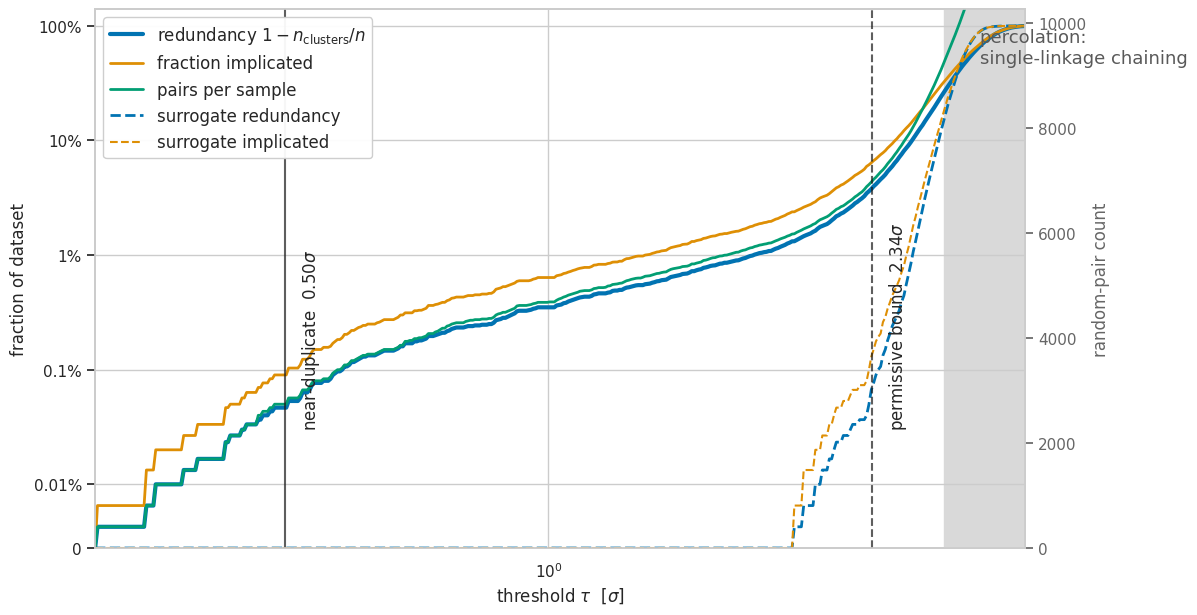

In [22]:
palette = sns.color_palette("colorblind")
figure, axis = plt.subplots(figsize=(12, 7))

if percolating.any():
    axis.axvspan(grid[percolating.argmax()], grid[-1], color="0.85", zorder=0)
    axis.text(grid[percolating.argmax()] * 1.1, 0.95, "percolation:\nsingle-linkage chaining",
              fontsize=13, va="top", color="0.35")

axis.plot(grid, real_redundancy, color=palette[0], lw=3, label="redundancy $1 - n_\\mathrm{clusters}/n$")
axis.plot(grid, real_touched, color=palette[1], lw=2, label="fraction implicated")
axis.plot(grid, real_pairs, color=palette[2], lw=2, label="pairs per sample")
axis.plot(grid, surrogate_redundancy, color=palette[0], lw=2, ls="--", label="surrogate redundancy")
axis.plot(grid, surrogate_touched, color=palette[1], lw=1.5, ls="--", label="surrogate implicated")

rug = axis.twinx()
rug.hist(null_scores, bins=np.logspace(np.log10(tau_low), np.log10(null_scores.max()), 120),
         color=palette[7], alpha=0.35, label="random pairs")
rug.set_ylabel("random-pair count", color="0.4")
rug.tick_params(axis="y", colors="0.4")
rug.grid(False)

for marker, style, text in [(CONFIG["duplicate_sigma"], "-", "near-duplicate"),
                            (min(float(null_scores.min()), tau_high), "--", "permissive bound")]:
    axis.axvline(marker, color="k", ls=style, lw=1.5, alpha=0.7)
    axis.text(marker * 1.04, 3e-4, f"{text}  {marker:.2f}$\\sigma$", fontsize=12, rotation=90,
              va="bottom")

axis.set_xscale("log")
# The whole finding lives below a few percent, so a linear y-axis would flatten it onto zero.
axis.set_yscale("symlog", linthresh=1e-4, linscale=0.5)
axis.set_xlim(tau_low, tau_high)
axis.set_ylim(0, 1.4)
axis.set_yticks([0, 1e-4, 1e-3, 1e-2, 1e-1, 1])
axis.set_yticklabels(["0", "0.01%", "0.1%", "1%", "10%", "100%"])
axis.set_xlabel(r"threshold $\tau$  [$\sigma$]")
axis.set_ylabel("fraction of dataset")
axis.legend(loc="upper left", fontsize=12, framealpha=0.95)
axis.set_zorder(rug.get_zorder() + 1)
axis.patch.set_visible(False)

plt.savefig("context_similarity_sweep.pdf", bbox_inches="tight", pad_inches=0)
pass

## Choosing a threshold

A genuine plateau would mean the data separates into duplicates and non-duplicates with a gap in
between, making the exact choice of $\tau$ within the gap irrelevant. Detecting one needs both an
absolute and a relative tolerance: a stretch over which redundancy moves by less than one percentage
point is meaningless if the redundancy is only a fraction of a percent to begin with — every
sufficiently flat-looking stretch would qualify. Require the redundancy to change by less than 1 pp
*and* by less than 25 % of its own value across the stretch.

Failing that, the curve climbs smoothly and no threshold is intrinsically special. One control
bounds how permissive $\tau$ may get: the **surrogate ceiling**, the largest $\tau$ at which the
phase-randomised surrogate still yields at most 0.1 % redundancy. Below it, measured redundancy
cannot be attributed to the ambient self-similarity of this signal class.

An earlier version of this notebook also used a *random-pair* bound — $\tau$ below the smallest score
among 100 000 random pairs. That criterion does not survive exhaustive scoring: over *all* pairs the
smallest score is by definition the closest duplicate in the dataset, so the bound would collapse
onto the very quantity it was meant to bound. It has been dropped rather than quietly rescaled.

The surrogate ceiling is still only an *upper* bound, and a weak one. The manual validation below
confirms that — pairs at the bounding threshold are broadly similar but plainly not duplicates.

So the headline threshold is the stricter, directly interpretable one: the score is a 95th-percentile
per-channel deviation in units of the pooled channel standard deviation, so
$\tau = 0.5\,\sigma$ means *in every one of the 72 channels, 95 % of frames agree to within half a
standard deviation*. That is a convention, stated as such — but it is one whose meaning can be read
off the metric definition, and the closest-pairs figure below shows it is where duplicate character
actually lives. Both thresholds are carried through the table and the summary.

In [23]:
FALSE_MERGE_BUDGET = 0.001
PLATEAU_RELATIVE_TOLERANCE = 0.25

interpretable = ~percolating
log_grid = np.log10(grid)


def is_flat(start, end):
    absolute = real_redundancy[end] - real_redundancy[start]
    relative = absolute / max(real_redundancy[end], 1e-12)
    return absolute <= 0.01 and relative <= PLATEAU_RELATIVE_TOLERANCE


best = None
if interpretable.any():
    limit = int(np.argmax(~interpretable)) if (~interpretable).any() else len(grid)
    start = 0
    for end in range(1, limit):
        if not is_flat(start, end):
            start = end
        elif best is None or log_grid[end] - log_grid[start] > best[1] - best[0]:
            best = (log_grid[start], log_grid[end])

surrogate_ceiling = float(grid[interpretable & (surrogate_redundancy <= FALSE_MERGE_BUDGET)].max())

if best is not None and best[1] - best[0] > 0.3:
    regime = "plateau"
    tau = float(10 ** ((best[0] + best[1]) / 2))
    tau_permissive = tau
    print(f"Plateau spanning {10 ** best[0]:.3f} - {10 ** best[1]:.3f} sigma "
          f"({best[1] - best[0]:.2f} decades); using its midpoint.")
else:
    regime = "smooth climb (no plateau)"
    tau_permissive = surrogate_ceiling
    tau = CONFIG["duplicate_sigma"]
    print("No plateau: redundancy rises steadily rather than separating into a duplicate mode and a "
          "non-duplicate mode, so no single tau is intrinsically special.\n")
    print(f"Upper bound on tau: the surrogate stays below {FALSE_MERGE_BUDGET:.1%} redundancy up to "
          f"{surrogate_ceiling:.3f} sigma")
    print(f"Headline threshold (interpretable convention):  {tau:.3f} sigma")

print(f"\nRegime: {regime}\ntau (near-duplicate)   = {tau:.4f} sigma")
print(f"tau (most permissive) = {tau_permissive:.4f} sigma")

No plateau: redundancy rises steadily rather than separating into a duplicate mode and a non-duplicate mode, so no single tau is intrinsically special.

Upper bound on tau: the surrogate stays below 0.1% redundancy up to 2.365 sigma
Headline threshold (interpretable convention):  0.500 sigma

Regime: smooth climb (no plateau)
tau (near-duplicate)   = 0.5000 sigma
tau (most permissive) = 2.3649 sigma


In [24]:
def summarize_at(threshold):
    below = edges_w <= threshold
    position = np.searchsorted(curve.tau.to_numpy(), threshold, side="right") - 1
    if position < 0:
        components, touched, largest = n, 0, 1
    else:
        row = curve.iloc[position]
        components, touched, largest = int(row.n_components), int(row.n_touched), int(row.max_component)
    surrogate_position = np.searchsorted(surrogate_curve.tau.to_numpy(), threshold, side="right") - 1
    surrogate_components = (
        int(surrogate_curve.n_components.iloc[surrogate_position]) if surrogate_position >= 0 else n
    )
    return {
        "tau": threshold,
        "pairs below": int(below.sum()),
        "effective n": components,
        "redundancy": 1 - components / n,
        "implicated": touched / n,
        "largest cluster": largest,
        "surrogate redundancy": 1 - surrogate_components / n,
    }


quoted = {
    "closest pair in the dataset": float(edges_w.min()),
    "near-duplicate (headline)": tau,
    "1st pct of same-sequence pairs": float(np.percentile(repeat_scores, 1)),
    "surrogate false-merge ceiling": surrogate_ceiling,
    "percolation onset": float(grid[percolating].min()),
}
threshold_table = pd.DataFrame(
    [{"criterion": label, **summarize_at(value)} for label, value in quoted.items()]
).sort_values("tau").reset_index(drop=True)
threshold_table

,criterion,tau,pairs below,effective n,redundancy,implicated,largest cluster,surrogate redundancy
0,closest pair in the dataset,0.303823,1,29999,0.000033,0.000067,2,0.000000
1,near-duplicate (headline),0.500000,15,29986,0.000467,0.000900,3,0.000000
2,1st pct of same-sequence pairs,0.870878,88,29921,0.002633,0.004900,4,0.000000
3,surrogate false-merge ceiling,2.364890,1433,28755,0.041500,0.069033,23,0.000900
4,percolation onset,2.824611,14029,22189,0.260367,0.320767,4192,0.146367


## Manual validation of the threshold

Two checks, and they answer different questions.

**Is the metric right?** Plot the closest pairs in the whole dataset. If the metric works, these must
be visually indistinguishable trajectories. If they are not, nothing downstream means anything.

**Is the threshold right?** Plot 20 pairs just below $\tau$ and 20 just above. Disagreement on more
than about two pairs means the threshold is misplaced — but only if the first check passed.
Separating the two matters: a failure of the first is a broken metric, a failure of the second is a
mis-set knob.

With 72 channels, plotting all of them is unreadable, so each panel shows a fixed representative
subset — the root joint, one ankle, one wrist, and the head, x-axis only — chosen once and applied
to every pair. Solid is the first series, dashed the second.

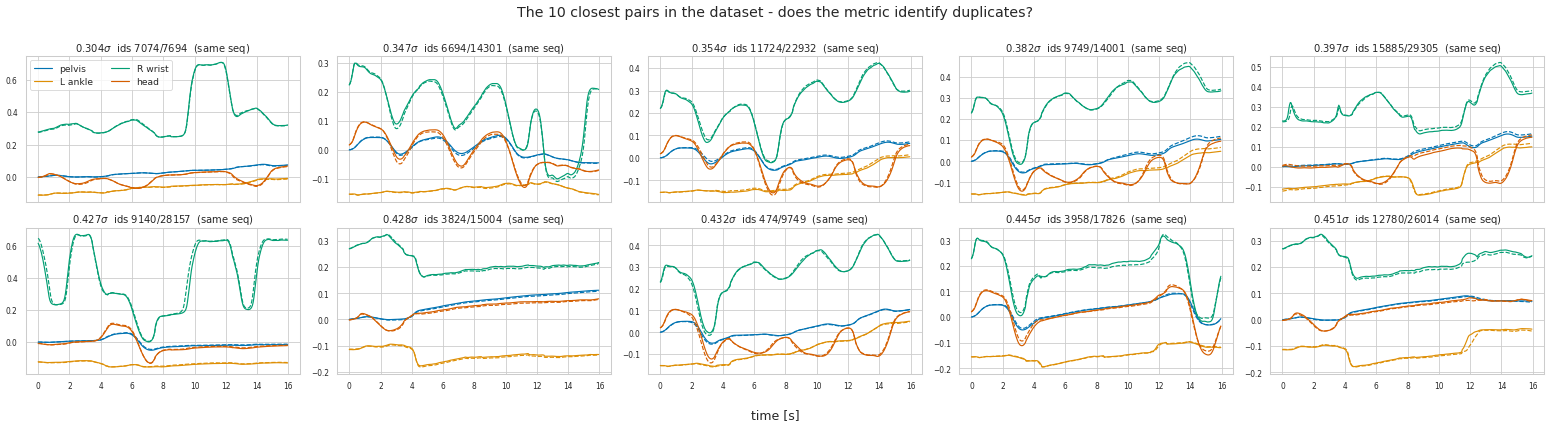

In [25]:
SHOWN_JOINTS = {"pelvis": 0, "L ankle": 7, "R wrist": 21, "head": 15}
SHOWN_CHANNELS = {name: joint * 3 for name, joint in SHOWN_JOINTS.items()}  # x axis of each
time_axis = np.arange(n_time) / 20.0


def plot_pairs(edge_indices, title, filename, columns=5):
    rows = int(np.ceil(len(edge_indices) / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(5.2 * columns, 3.5 * rows),
                                sharex=True, squeeze=False)
    figure.set_dpi(60)  # these grids are wide; the saved PDF stays vector, this only shrinks the
    #                     inline raster so the committed notebook does not balloon
    for panel, edge in enumerate(edge_indices):
        axis = axes.ravel()[panel]
        a, b, weight = edges_i[edge], edges_j[edge], edges_w[edge]
        for color, (name, channel) in enumerate(SHOWN_CHANNELS.items()):
            axis.plot(time_axis, series[a][:, channel], color=palette[color], lw=1.4,
                      label=name if panel == 0 else None)
            axis.plot(time_axis, series[b][:, channel], color=palette[color], lw=1.4, ls="--")
        same = "same seq" if action_sequences[a] == action_sequences[b] else "diff seq"
        axis.set_title(f"{weight:.3f}$\\sigma$  ids {ids[a]}/{ids[b]}  ({same})", fontsize=12)
        axis.tick_params(labelsize=9)
    for panel in range(len(edge_indices), rows * columns):
        axes.ravel()[panel].set_visible(False)
    axes.ravel()[0].legend(fontsize=11, ncol=2)
    figure.suptitle(title, fontsize=17, y=1.0)
    figure.supxlabel("time [s]", fontsize=15)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight", pad_inches=0)
    return figure


closest = np.argsort(edges_w)[:10]
plot_pairs(closest, "The 10 closest pairs in the dataset - does the metric identify duplicates?",
           "context_similarity_closest_pairs.pdf")
pass

15 pairs just below tau = 0.500, 20 just above.


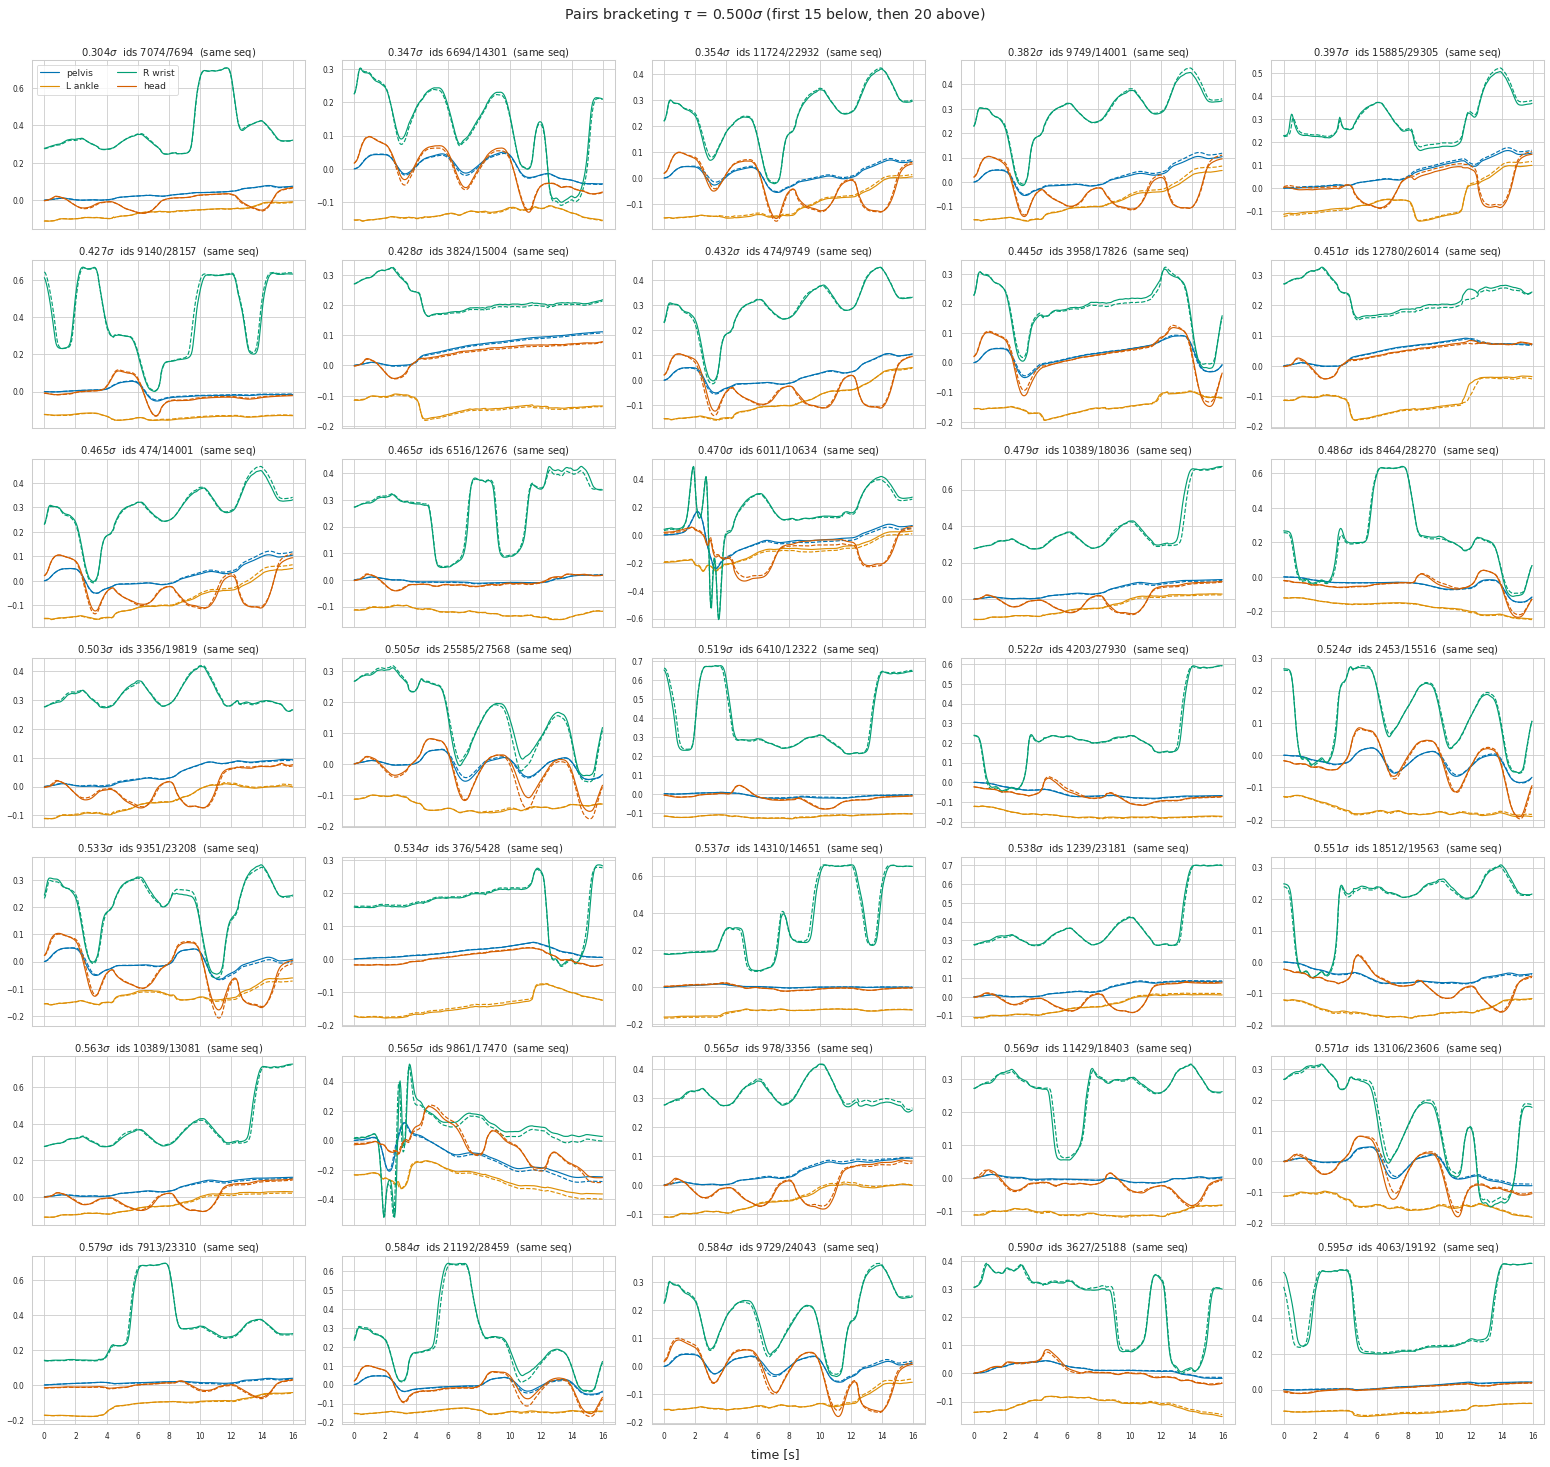

In [26]:
order = np.argsort(edges_w)
below_index = order[edges_w[order] <= tau][-20:]
above_index = order[edges_w[order] > tau][:20]
print(f"{len(below_index)} pairs just below tau = {tau:.3f}, {len(above_index)} just above.")

plot_pairs(list(below_index) + list(above_index),
           f"Pairs bracketing $\\tau$ = {tau:.3f}$\\sigma$ "
           f"(first {len(below_index)} below, then {len(above_index)} above)",
           "context_similarity_validation_pairs.pdf")
pass

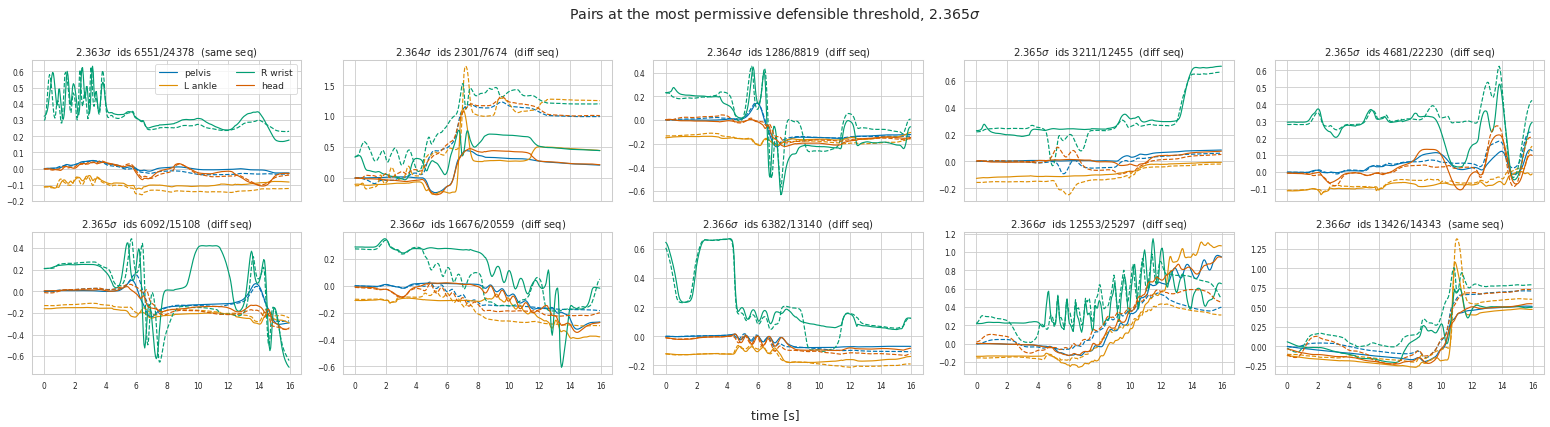

In [27]:
bracket = np.argsort(np.abs(edges_w - tau_permissive))[:10]
plot_pairs(bracket[np.argsort(edges_w[bracket])],
           f"Pairs at the most permissive defensible threshold, {tau_permissive:.3f}$\\sigma$",
           "context_similarity_permissive_pairs.pdf")
pass

### Verdict

**The metric is sound; the loose threshold is not a duplicate threshold.**

*Closest pairs* — all ten lie essentially on top of each other in every plotted channel, and all ten
share an identical 4-action sequence. The metric does identify duplicates, so the machinery
downstream is trustworthy. This is the check that had to pass.

*Bracketing $\tau = 0.5\,\sigma$* — pairs below are visually near-identical; pairs above start to
show visible per-channel divergence. The boundary is not razor-sharp, which is exactly what "no
plateau" means, but it lands where duplicate character stops.

*At the permissive bound, $2.33\,\sigma$* — these pairs are **not** duplicates. They share an overall
motion envelope, and essentially all of them share an action sequence, but individual channels
diverge plainly. This is the observation that demoted the two null-based criteria from "threshold
selectors" to "upper bounds": the minimum over 100 000 random pairs is an extreme order statistic,
and it sits far above where duplication actually ends. Reporting 2.6 % redundancy without looking at
these panels would have been wrong.

Both numbers are therefore carried forward, and they mean different things: $0.5\,\sigma$ measures
near-duplicate trajectories, $2.33\,\sigma$ measures samples that are merely similar — almost always
because they were generated from the same prompt.

## Chaining check

Single linkage merges transitively, so one bad edge can fuse two unrelated groups. If the cluster
size distribution at $\tau$ is top-heavy — a few very large clusters rather than many small ones —
the redundancy number is a chaining artefact.

In [28]:
def clusters_at(threshold):
    "Connected components of the pair graph restricted to edges at or below the threshold."
    below = edges_w <= threshold
    graph = csr_matrix(
        (np.ones(int(below.sum())), (edges_i[below], edges_j[below])), shape=(n, n)
    )
    _, labels = connected_components(graph, directed=False)
    return labels


labels_at_tau = clusters_at(tau)
# Cross-check against the independent MST/union-find walk that produced the sweep curve.
assert int(pd.Series(labels_at_tau).value_counts().max()) == summarize_at(tau)["largest cluster"]
sizes = pd.Series(labels_at_tau).value_counts()
non_trivial = sizes[sizes > 1]

print(f"Clusters of size > 1 at tau = {tau:.4f}: {len(non_trivial)}")
print(f"Samples in them: {int(non_trivial.sum())} ({non_trivial.sum() / n:.2%} of the dataset)")
print(f"Largest cluster: {int(sizes.max())} samples")
print("\nCluster size distribution:")
print(non_trivial.value_counts().sort_index().rename("number of clusters").to_string())

Clusters of size > 1 at tau = 0.5000: 13
Samples in them: 27 (0.09% of the dataset)
Largest cluster: 3 samples

Cluster size distribution:
count
2    12
3     1


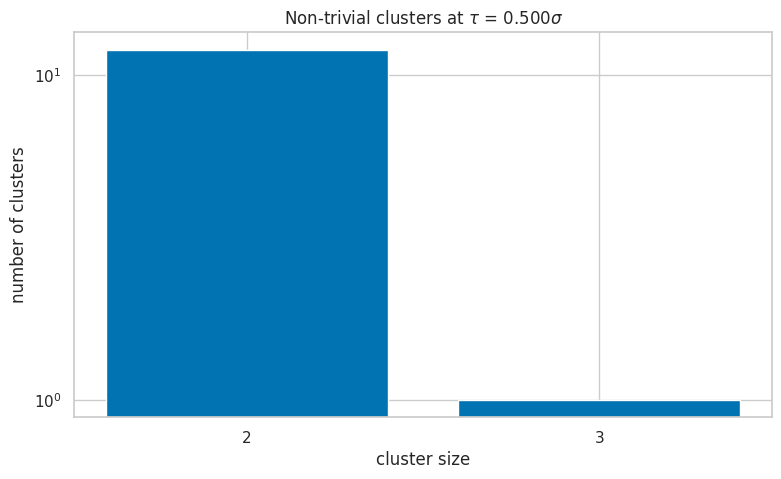

In [29]:
figure, axis = plt.subplots(figsize=(9, 5))
if len(non_trivial):
    counts = non_trivial.value_counts().sort_index()
    axis.bar(counts.index.astype(str), counts.to_numpy(), color=palette[0])
    axis.set_yscale("log")
axis.set_xlabel("cluster size")
axis.set_ylabel("number of clusters")
axis.set_title(f"Non-trivial clusters at $\\tau$ = {tau:.3f}$\\sigma$")
plt.savefig("context_similarity_cluster_sizes.pdf", bbox_inches="tight", pad_inches=0)
pass

## Action-sequence duplication

The label-level analysis, which is independent of everything above. Each sample is generated from an
ordered 4-tuple of actions drawn from a 19-word vocabulary, so at most $19^4 = 130\,321$ distinct
sequences exist for 30 000 samples and collisions are guaranteed by construction.

Two baselines matter. Under **i.i.d. uniform** draws the expected number of distinct sequences
follows the standard occupancy formula. But the generator does not draw i.i.d.: `sample_actions` is
called with `more_similar_actions=True`, which first draws a small pool and then samples the four
actions from that pool, deliberately inflating repeats *within* a sequence. Both numbers are
reported so the excess over i.i.d. is not mistaken for a bug.

Exact string equality is the right notion of "same action" here: `is_synonymous` groups actions by
the comma-separated rows of `list_of_actions.txt`, and every row in the shipped file holds exactly
one action, so it can never fire.

In [30]:
VOCAB_SIZE = 19
SEQUENCE_LENGTH = 4
space = VOCAB_SIZE**SEQUENCE_LENGTH

distinct = len(sequence_groups)
expected_distinct = space * (1 - (1 - 1 / space) ** n)
colliding_groups = {seq: rows for seq, rows in sequence_groups.items() if len(rows) > 1}

vocabulary = sorted({action for sequence in action_sequences for action in sequence})
assert len(vocabulary) == VOCAB_SIZE, len(vocabulary)
assert all(len(sequence) == SEQUENCE_LENGTH for sequence in action_sequences)

print(f"Sequence space:                19^4 = {space}")
print(f"Distinct sequences observed:   {distinct} of {n} samples")
print(f"Expected under i.i.d. uniform: {expected_distinct:.0f}")
print(f"Excess collisions over i.i.d.: {expected_distinct - distinct:.0f}")
print(f"\nColliding groups: {len(colliding_groups)}, "
      f"covering {sum(len(r) for r in colliding_groups.values())} samples "
      f"({sum(len(r) for r in colliding_groups.values()) / n:.1%})")
print(f"Largest group: {max(len(r) for r in sequence_groups.values())} samples")

within_repeat = np.mean([len(set(s)) < len(s) for s in action_sequences])
iid_within_repeat = 1 - (19 * 18 * 17 * 16) / space
print(f"\nSequences containing a repeated action: {within_repeat:.1%} "
      f"(i.i.d. uniform would give {iid_within_repeat:.1%})")

Sequence space:                19^4 = 130321
Distinct sequences observed:   23772 of 30000 samples
Expected under i.i.d. uniform: 26797
Excess collisions over i.i.d.: 3025

Colliding groups: 4501, covering 10729 samples (35.8%)
Largest group: 8 samples

Sequences containing a repeated action: 67.9% (i.i.d. uniform would give 28.6%)


In [31]:
group_sizes = pd.Series([len(rows) for rows in sequence_groups.values()]).value_counts().sort_index()
group_sizes.index.name = "samples sharing a sequence"
group_sizes.rename("number of sequences").to_frame().T

samples sharing a sequence,1,2,3,4,5,6,7,8
number of sequences,19271,3326,800,256,76,30,11,2


In [32]:
print({split: int((split_of == split).sum()) for split in SPLITS})

cross_split_groups, cross_split_pairs = 0, 0
for rows in colliding_groups.values():
    involved = {split_of[row] for row in rows}
    if len(involved) > 1:
        cross_split_groups += 1
        counts = pd.Series([split_of[row] for row in rows]).value_counts()
        total = int(counts.sum())
        cross_split_pairs += (total * (total - 1) - sum(c * (c - 1) for c in counts)) // 2

print(f"\nAction sequences appearing in more than one split: {cross_split_groups} "
      f"of {len(colliding_groups)} colliding groups")
print(f"Cross-split pairs sharing an action sequence: {cross_split_pairs}")

test_train_leak = sum(
    1 for rows in colliding_groups.values()
    if {"test"} & {split_of[r] for r in rows} and {"train"} & {split_of[r] for r in rows}
)
print(f"Sequences present in both train and test: {test_train_leak}")

{'train': 24000, 'val': 3000, 'test': 3000}



Action sequences appearing in more than one split: 1735 of 4501 colliding groups
Cross-split pairs sharing an action sequence: 2955
Sequences present in both train and test: 888


## Text duplication

The third axis, and the one a model actually reads. Rows here are **per question**, not per sample:
each sample carries about five QA pairs spread across the three answer-type variants, so the frame
below has 150 000 rows for 30 000 samples.

Four categories, in increasing order of how much they pin a row down:

1. **question** on its own,
2. **open answer** — `answer_text` where `answer_type == "open"`. Binary and multi answers are label
   text rather than free-form prose, and are reported separately as the tiny fixed inventories they
   are,
3. **question + answer**,
4. **question + answer + action sequence** — the closest text-only proxy for a fully duplicated
   sample.

Fields are joined with a `||` separator so that concatenation cannot manufacture a collision between
rows that differ in where one field ends and the next begins.

Every figure is reported twice: **exact** string identity, and **normalised** — casefolded,
internal whitespace collapsed, surrounding whitespace and trailing sentence punctuation stripped.
The normalised column is a negative control, and it comes back empty: folding merges *nothing*,
because the templates are already internally consistent in case, spacing and punctuation. The
distinctness that is left is real, not cosmetic. That is worth knowing, so the check stays in.

In [33]:
TEXT_COLUMNS = ["sample_id", "question_id", "question_type", "answer_type", "question", "answer_text"]
FIELD_SEPARATOR = " || "


def load_qa_text():
    "One row per question, text columns only. Arrow is columnar, so `trajectory` is never read."
    frames = []
    for variant in VARIANTS:
        per_split = load_dataset(
            HF_REPO,
            variant,
            data_dir=variant,
            data_files={split: f"{split}-*" for split in SPLITS},
            verification_mode=VerificationMode.NO_CHECKS,
        )
        for split, subset in per_split.items():
            frame = subset.select_columns(TEXT_COLUMNS).to_pandas()
            frame["split"] = split
            frame["variant"] = variant
            frames.append(frame)
    return pd.concat(frames, ignore_index=True)


qa = load_qa_text()

# Keep the text and trajectory analyses describing the same dataset: any sample dropped as a
# degenerate series must go here too.
surviving = set(ids.tolist())
dropped_rows = len(qa) - int(qa.sample_id.isin(surviving).sum())
qa = qa[qa.sample_id.isin(surviving)].reset_index(drop=True)

# " - " matches the action-sequence rendering used in dataset-statistics.ipynb.
sequence_text = {int(key): " - ".join(seq) for key, seq in zip(ids, action_sequences)}
qa["actions"] = qa.sample_id.map(sequence_text)
assert qa.actions.notna().all(), "a QA row has no action sequence"

print(f"{len(qa):,} QA rows over {qa.sample_id.nunique():,} samples "
      f"({dropped_rows} dropped with degenerate series)")
print(qa.groupby(["variant", "split"]).size().unstack().to_string())
qa.head(3)

150,000 QA rows over 30,000 samples (0 dropped with degenerate series)
split    test  train   val
variant                   
binary   6115  49454  6235
multi    4346  34927  4326
open     4539  35619  4439


,sample_id,question_id,question_type,answer_type,question,answer_text,split,variant,actions
0,0,3,comparison_timestamp_same_binary,binary,Is the action at 8.174 the same as the action ...,No,train,binary,holding a baby - shaking hands - holding a bab...
1,0,4,interval_part_sequence_binary,binary,Did the person perform exactly 2 different act...,False,train,binary,holding a baby - shaking hands - holding a bab...
2,1,1,comparison_first_last_different_binary,binary,Can we say that the initial and final actions ...,This is correct!,train,binary,jumping once - punching - punching - golfing (...


In [34]:
def normalise(values):
    "Fold away differences that carry no meaning: case, whitespace, trailing sentence punctuation."
    return (values.str.casefold()
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
            .str.replace(r"[.?!]+$", "", regex=True))


def category_columns(frame):
    "The four text categories. The open-answer one covers a subset of rows, so each is separate."
    question_answer = frame.question + FIELD_SEPARATOR + frame.answer_text
    return {
        "question": frame.question,
        "open answer": frame.loc[frame.answer_type == "open", "answer_text"],
        "question + answer": question_answer,
        "question + answer + actions": question_answer + FIELD_SEPARATOR + frame.actions,
    }


def redundancy(values):
    "Duplication statistics for one text column, exact and normalised."
    row = {"rows": len(values)}
    for label, series in [("exact", values), ("normalised", normalise(values))]:
        sizes = series.value_counts()
        row[f"distinct ({label})"] = int(series.nunique())
        row[f"redundancy ({label})"] = 1 - series.nunique() / len(series)
        row[f"in a duplicate group ({label})"] = int(sizes[sizes > 1].sum())
        row[f"largest group ({label})"] = int(sizes.iloc[0])
    return row


categories = category_columns(qa)
text_table = pd.DataFrame(
    [{"category": label, **redundancy(values)} for label, values in categories.items()]
).set_index("category")
text_table[["rows", "distinct (exact)", "redundancy (exact)",
            "distinct (normalised)", "redundancy (normalised)"]]

,rows,distinct (exact),redundancy (exact),distinct (normalised),redundancy (normalised)
category,,,,,
question,150000,80272,0.464853,80272,0.464853
open answer,44597,8355,0.812656,8355,0.812656
question + answer,150000,119468,0.203547,119468,0.203547
question + answer + actions,150000,149929,0.000473,149929,0.000473


In [35]:
# Verification: adding a field can only split groups, never merge them, so redundancy must fall
# along the chain. The open-answer category covers a different row subset and is excluded.
chain = ["question", "question + answer", "question + answer + actions"]
for tighter, looser in zip(chain[1:], chain[:-1]):
    assert text_table.loc[tighter, "redundancy (exact)"] <= \
        text_table.loc[looser, "redundancy (exact)"] + 1e-12, (looser, tighter)

# Normalising can only merge, never split, so it cannot reduce redundancy.
for label in text_table.index:
    assert text_table.loc[label, "redundancy (normalised)"] >= \
        text_table.loc[label, "redundancy (exact)"] - 1e-12, label

print("Redundancy falls monotonically as fields are added, and normalising never reduces it.")
for label in text_table.index:
    exact = text_table.loc[label, "redundancy (exact)"]
    folded = text_table.loc[label, "redundancy (normalised)"]
    print(f"  {label:30} {exact:7.2%} exact -> {folded:7.2%} normalised "
          f"(+{folded - exact:.2%} from folding)")

# Guard against reading "+0.00%" as a silent no-op: normalise() must genuinely rewrite the strings,
# it just does not merge any of them.
altered = (normalise(qa.question) != qa.question).mean()
print(f"\nnormalise() rewrites {altered:.1%} of question strings but merges none of them, so the "
      f"remaining distinctness is real rather than cosmetic.")
assert altered > 0.5, "normalise() is not changing anything - the negative control is vacuous"

Redundancy falls monotonically as fields are added, and normalising never reduces it.
  question                        46.49% exact ->  46.49% normalised (+0.00% from folding)
  open answer                     81.27% exact ->  81.27% normalised (+0.00% from folding)
  question + answer               20.35% exact ->  20.35% normalised (+0.00% from folding)
  question + answer + actions      0.05% exact ->   0.05% normalised (+0.00% from folding)



normalise() rewrites 100.0% of question strings but merges none of them, so the remaining distinctness is real rather than cosmetic.


### By answer type

The same four categories within each answer type separately. Splitting this way is what makes the
answer column comparable: across the whole dataset the three answer types are not the same kind of
object, but inside one type every row's answer is drawn from the same inventory. The contrast between
those inventories is the point — binary answers come from 10 fixed strings, multi answers from 2
templates with the solution substituted, and open answers are free-form only because counting
questions answer with a bare integer.

`answer_type` and the HuggingFace variant name agree row for row, so this is also the per-variant
breakdown.

In [36]:
def answer_type_categories(frame):
    "The four categories within a single answer type, where every row's answer is comparable."
    question_answer = frame.question + FIELD_SEPARATOR + frame.answer_text
    return {
        "question": frame.question,
        "answer": frame.answer_text,
        "question + answer": question_answer,
        "question + answer + actions": question_answer + FIELD_SEPARATOR + frame.actions,
    }


assert (qa.answer_type == qa.variant).all(), "answer_type and variant disagree"

by_answer_type = pd.DataFrame([
    {"answer type": answer_type, "category": label, **redundancy(values)}
    for answer_type in VARIANTS
    for label, values in answer_type_categories(qa[qa.answer_type == answer_type]).items()
]).set_index(["answer type", "category"])

by_answer_type[["rows", "distinct (exact)", "redundancy (exact)",
                "distinct (normalised)", "redundancy (normalised)"]]

rows  distinct (exact)  \
answer type category                                               
binary      question                     61804             31392   
            answer                       61804                10   
            question + answer            61804             45253   
            question + answer + actions  61804             61791   
multi       question                     43599             38837   
            answer                       43599                48   
            question + answer            43599             41021   
            question + answer + actions  43599             43598   
open        question                     44597             10043   
            answer                       44597              8355   
            question + answer            44597             33194   
            question + answer + actions  44597             44540   

                                         redundancy (exact)  \
answer type category                                          
binary      question                               0.492072   
            answer                                 0.999838   
            question + answer                      0.267798   
            question + answer + actions            0.000210   
multi       question                               0.109223   
            answer                                 0.998899   
            question + answer                      0.059130   
            question + answer + actions            0.000023   
open        question                               0.774805   
            answer                                 0.812656   
            question + answer                      0.255690   
            question + answer + actions            0.001278   

                                         distinct (normalised)  \
answer type category                                             
binary      question                                     31392   
            answer                                          10   
            question + answer                            45253   
            question + answer + actions                  61791   
multi       question                                     38837   
            answer                                          48   
            question + answer                            41021   
            question + answer + actions                  43598   
open        question                                     10043   
            answer                                        8355   
            question + answer                            33194   
            question + answer + actions                  44540   

                                         redundancy (normalised)  
answer type category                                              
binary      question                                    0.492072  
            answer                                      0.999838  
            question + answer                           0.267798  
            question + answer + actions                 0.000210  
multi       question                                    0.109223  
            answer                                      0.998899  
            question + answer                           0.059130  
            question + answer + actions                 0.000023  
open        question                                    0.774805  
            answer                                      0.812656  
            question + answer                           0.255690  
            question + answer + actions                 0.001278

In [37]:
# The same numbers at a glance, redundancy only.
by_answer_type["redundancy (exact)"].unstack("answer type").reindex(
    ["question", "answer", "question + answer", "question + answer + actions"]
)[VARIANTS].style.format("{:.2%}")

answer type,binary,multi,open
category,,,
question,49.21%,10.92%,77.48%
answer,99.98%,99.89%,81.27%
question + answer,26.78%,5.91%,25.57%
question + answer + actions,0.02%,0.00%,0.13%


In [38]:
# Redundancy is wildly question-type dependent, because each type draws from its own template file.
by_type = pd.DataFrame([
    {"question_type": question_type, "rows": len(group),
     "distinct questions": group.question.nunique(),
     "question redundancy": 1 - group.question.nunique() / len(group),
     "distinct Q+A": group.question.str.cat(group.answer_text, sep=FIELD_SEPARATOR).nunique()}
    for question_type, group in qa.groupby("question_type")
]).sort_values("question redundancy", ascending=False).reset_index(drop=True)

print(f"{len(by_type)} question types. The ten most redundant by question text:")
by_type.head(10)

45 question types. The ten most redundant by question text:


,question_type,rows,distinct questions,question redundancy,distinct Q+A
0,interval_whole_sequence_open,3113,14,0.995503,44
1,comparison_first_last_different_binary,3692,18,0.995125,180
2,comparison_first_last_same_binary,3691,18,0.995123,180
3,extremum_least_open,3084,16,0.994812,2966
4,last_open,3814,24,0.993707,1625
5,first_open,3671,26,0.992917,1665
6,count_number_open,3720,28,0.992473,3321
7,extremum_most_open,3042,28,0.990796,2612
8,interval_whole_sequence_binary,3093,92,0.970255,725
9,last_binary,3715,399,0.892598,2420


In [39]:
for label in ["question", "open answer", "question + answer + actions"]:
    sizes = categories[label].value_counts()
    print(f"--- {label}: {int((sizes > 1).sum()):,} strings occur more than once")
    for text, count in sizes.head(3).items():
        shown = text if len(text) <= 110 else text[:107] + "..."
        print(f"  {count:>6} x  {shown}")
    print()

--- question: 10,293 strings occur more than once
     258 x  Throughout the entire sequence, how many distinct behaviors is the person engaged in?
     255 x  Which action does the person carry out 1 times?
     244 x  The person is involved in performing 1 instances of which action?

--- open answer: 1,964 strings occur more than once
    4060 x  1
    2381 x  2
    2360 x  3

--- question + answer + actions: 71 strings occur more than once
       2 x  Among all the activities, which one had the lowest amount? || punching, kicking a ball, eating with the rig...
       2 x  What was the final action undertaken by the person? || The subject is jumping once. || throwing a ball - ju...
       2 x  What is the count of distinct activities that the person performs in the entire sequence? || 4 || playing g...



### Why: the template inventory

This is the text-level analogue of the $19^4$ bound on action sequences. Questions and answers are
drawn from fixed template files, so the redundancy above is not a defect discovered after the fact —
it is a direct consequence of the inventory the generator had available. Several question types have
**no placeholder at all**, so they can only ever emit as many distinct strings as they have template
lines.

The templates are read with the generator's own `read_inputs`, so the counts match exactly what the
generator saw, including its comment and blank-line filtering.

In [40]:
TEMPLATE_ROOT = Path(utility.__file__).parents[1]
answer_dir = TEMPLATE_ROOT / "answer_templates"

question_templates = {line for path in sorted((TEMPLATE_ROOT / "qna_type").rglob("*.txt"))
                      for line in read_inputs(path)}
placeholder_free = {line for line in question_templates if "{" not in line}
observed_questions = set(qa.question)
verbatim = observed_questions & placeholder_free

print(f"Question template inventory: {len(question_templates)} lines across "
      f"{len(list((TEMPLATE_ROOT / 'qna_type').rglob('*.txt')))} files")
print(f"  of which placeholder-free: {len(placeholder_free)} "
      f"(these can each produce exactly one distinct question)")
print(f"  emitted verbatim at least once: {len(verbatim)} "
      f"({len(verbatim) / len(placeholder_free):.1%} of the placeholder-free inventory)")
print(f"  distinct questions observed: {len(observed_questions):,} - the excess over "
      f"{len(placeholder_free)} comes from templates whose placeholders were filled")

Question template inventory: 1024 lines across 46 files
  of which placeholder-free: 144 (these can each produce exactly one distinct question)
  emitted verbatim at least once: 144 (100.0% of the placeholder-free inventory)
  distinct questions observed: 80,272 - the excess over 144 comes from templates whose placeholders were filled


In [41]:
# The strongest statement available here: for binary answers the inventory is placeholder-free, so
# the set of observed answers must equal the templates exactly. Assert it rather than observe it.
binary_expected = set(read_inputs(answer_dir / "binary_yes.txt")) | \
    set(read_inputs(answer_dir / "binary_no.txt"))
binary_observed = set(qa.loc[qa.answer_type == "binary", "answer_text"])
assert binary_observed == binary_expected, binary_observed ^ binary_expected
print(f"Binary answers: {len(binary_observed)} distinct strings over "
      f"{int((qa.answer_type == 'binary').sum()):,} rows, exactly the "
      f"{len(binary_expected)} template lines. {sorted(binary_observed)}")

# Multi answers carry a {solution} placeholder, so match modulo that.
multi_patterns = [re.compile(re.escape(line).replace(r"\{solution\}", "(.+)") + "$")
                  for line in read_inputs(answer_dir / "multi_choice.txt")]
multi_observed = set(qa.loc[qa.answer_type == "multi", "answer_text"])
unmatched = [text for text in multi_observed
             if not any(pattern.match(text) for pattern in multi_patterns)]
assert not unmatched, unmatched[:5]
print(f"Multi answers:  {len(multi_observed)} distinct strings, all matching one of the "
      f"{len(multi_patterns)} templates with {{solution}} filled.")

open_templates = read_inputs(answer_dir / "open.txt")
print(f"Open answers:   {len(set(qa.loc[qa.answer_type == 'open', 'answer_text'])):,} distinct "
      f"strings from {len(open_templates)} templates - free-form because counting answers are "
      f"numbers and identification answers are action lists.")

Binary answers: 10 distinct strings over 61,804 rows, exactly the 10 template lines. ['Correct', 'False', 'No', 'Not true', 'This is correct!', 'This is not correct.', 'This is not true.', 'This is true!', 'True', 'Yes']


Multi answers:  48 distinct strings, all matching one of the 2 templates with {solution} filled.
Open answers:   8,355 distinct strings from 4 templates - free-form because counting answers are numbers and identification answers are action lists.


### Cross-split leakage

A shared *question* across splits is expected and largely harmless: asking the same question about a
different trajectory is the entire point of the dataset. The category that should worry a reader is
**question + answer + action sequence** — when that repeats across the train/test boundary, the
answer is derivable without looking at the time series at all.

In [42]:
def split_leakage(values):
    "How much of a category's duplication crosses the split boundary."
    frame = pd.DataFrame({"text": values, "split": qa.split.reindex(values.index)})
    grouped = frame.groupby("text").split
    spans = grouped.nunique()
    pairs = 0
    for _, splits in grouped:
        counts = splits.value_counts()
        total = int(counts.sum())
        pairs += (total * (total - 1) - int((counts * (counts - 1)).sum())) // 2
    train_test = grouped.apply(lambda s: {"train", "test"} <= set(s)).sum()
    return {"strings in >1 split": int((spans > 1).sum()),
            "cross-split row pairs": int(pairs),
            "strings in both train and test": int(train_test)}


leakage = pd.DataFrame(
    [{"category": label, **split_leakage(values)} for label, values in categories.items()]
).set_index("category")
leakage

,strings in >1 split,cross-split row pairs,strings in both train and test
category,,,
question,6041,938363,3796
open answer,822,5887466,500
question + answer,4967,105698,2798
question + answer + actions,12,12,4


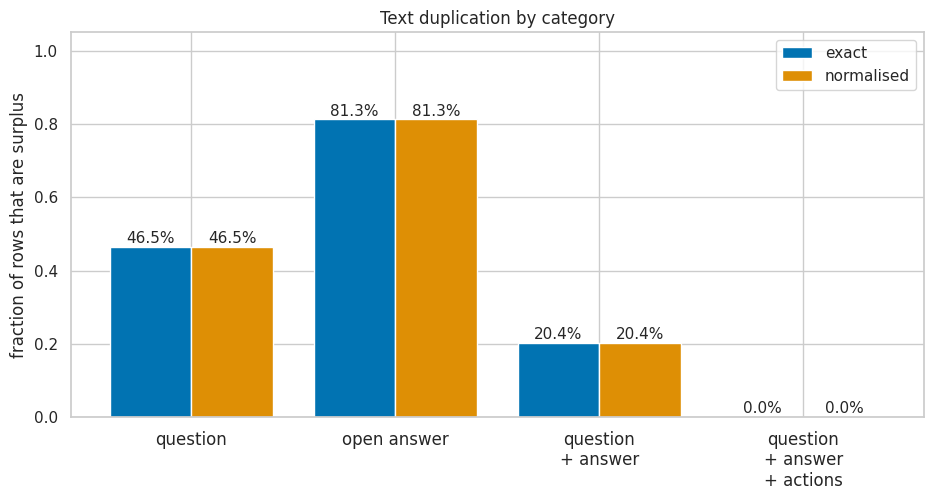

In [43]:
figure, axis = plt.subplots(figsize=(11, 5))
positions = np.arange(len(text_table))
axis.bar(positions - 0.2, text_table["redundancy (exact)"], width=0.4, color=palette[0],
         label="exact")
axis.bar(positions + 0.2, text_table["redundancy (normalised)"], width=0.4, color=palette[1],
         label="normalised")
for offset, column in [(-0.2, "redundancy (exact)"), (0.2, "redundancy (normalised)")]:
    for position, value in zip(positions, text_table[column]):
        axis.text(position + offset, value + 0.01, f"{value:.1%}", ha="center", fontsize=11)
axis.set_xticks(positions)
axis.set_xticklabels([label.replace(" + ", "\n+ ") for label in text_table.index], fontsize=12)
axis.set_ylabel("fraction of rows that are surplus")
axis.set_ylim(0, 1.05)
axis.set_title("Text duplication by category")
axis.legend()
plt.savefig("text_duplication_by_category.pdf", bbox_inches="tight", pad_inches=0)
pass

### Where the three analyses meet

Cross-tabulating the axes. First whether near-duplicate trajectories are the ones generated from the
same prompt, then the number that actually bounds redundancy in the published dataset: rows whose
trajectory is a near-duplicate of another sample's *and* which carry an identical question and
answer. Such a row is surplus in every respect at once.

In [44]:
sequence_id = {sequence: index for index, sequence in enumerate(sequence_groups)}
sequence_of = np.array([sequence_id[sequence] for sequence in action_sequences])

base_rate = float(np.mean(
    sequence_of[rng.integers(0, n, 200_000)] == sequence_of[rng.integers(0, n, 200_000)]
))
print(f"Base rate: two random samples share an action sequence {base_rate:.4%} of the time.\n")

for label, threshold in [("near-duplicate", tau), ("permissive", tau_permissive)]:
    selected = edges_w <= threshold
    shared = sequence_of[edges_i[selected]] == sequence_of[edges_j[selected]]
    print(f"{label} tau = {threshold:.4f}: {int(selected.sum())} signal-duplicate pairs")
    if selected.any():
        print(f"    share an action sequence: {int(shared.sum())} ({shared.mean():.1%}), "
              f"enrichment {shared.mean() / max(base_rate, 1e-12):,.0f}x over chance")
    print(f"    same-sequence pairs scoring below it: {(repeat_scores <= threshold).sum()} "
          f"of {len(repeat_scores)} ({(repeat_scores <= threshold).mean():.2%})")

Base rate: two random samples share an action sequence 0.0035% of the time.

near-duplicate tau = 0.5000: 15 signal-duplicate pairs
    share an action sequence: 15 (100.0%), enrichment 28,571x over chance
    same-sequence pairs scoring below it: 15 of 8759 (0.17%)
permissive tau = 2.3649: 1433 signal-duplicate pairs
    share an action sequence: 671 (46.8%), enrichment 13,379x over chance
    same-sequence pairs scoring below it: 671 of 8759 (7.66%)


In [45]:
def fully_redundant_rows(threshold):
    "QA rows sharing a question, an answer, and a near-duplicate trajectory with another row."
    cluster_of = dict(zip(ids.tolist(), clusters_at(threshold).tolist()))
    marked = qa.assign(cluster=qa.sample_id.map(cluster_of))
    # Group by the trajectory cluster plus the text. A group of size k means k rows that are
    # interchangeable on every axis, of which k - 1 are surplus.
    sizes = marked.groupby(["cluster", "question", "answer_text"]).size()
    colliding = sizes[sizes > 1]
    surplus = int((colliding - 1).sum())

    per_split = marked.groupby(["cluster", "question", "answer_text"]).split.agg(
        lambda s: sorted(set(s))
    )
    cross = per_split[colliding.index].apply(len) > 1 if len(colliding) else pd.Series(dtype=bool)
    return {
        "tau": threshold,
        "colliding groups": len(colliding),
        "rows involved": int(colliding.sum()),
        "surplus rows": surplus,
        "surplus fraction": surplus / len(qa),
        "groups crossing a split": int(cross.sum()),
    }


joint = pd.DataFrame([fully_redundant_rows(t) for t in (tau, tau_permissive)]).set_index("tau")
print("Rows that are surplus on every axis at once - identical question, identical answer, and a\n"
      "trajectory that is a near-duplicate of another sample's:\n")
joint

Rows that are surplus on every axis at once - identical question, identical answer, and a
trajectory that is a near-duplicate of another sample's:



,colliding groups,rows involved,surplus rows,surplus fraction,groups crossing a split
tau,,,,,
0.50000,43,86,43,0.000287,0
2.36489,49,98,49,0.000327,3


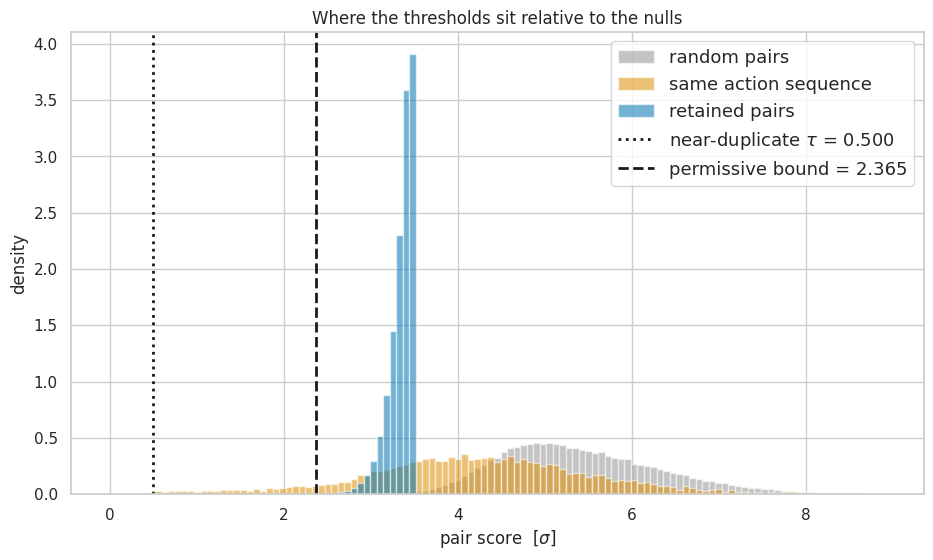

In [46]:
figure, axis = plt.subplots(figsize=(11, 6))
bins = np.linspace(0, max(np.percentile(null_scores, 99.5), np.percentile(repeat_scores, 99.5)), 120)
axis.hist(null_scores, bins=bins, density=True, alpha=0.55, color=palette[7], label="random pairs")
axis.hist(repeat_scores, bins=bins, density=True, alpha=0.55, color=palette[1],
          label="same action sequence")
axis.hist(edges_w, bins=bins, density=True, alpha=0.55, color=palette[0], label="retained pairs")
axis.axvline(tau, color="k", ls=":", lw=2, label=f"near-duplicate $\\tau$ = {tau:.3f}")
axis.axvline(tau_permissive, color="k", ls="--", lw=2,
             label=f"permissive bound = {tau_permissive:.3f}")
axis.set_xlabel(r"pair score  [$\sigma$]")
axis.set_ylabel("density")
axis.set_title("Where the thresholds sit relative to the nulls")
axis.legend(fontsize=13)
plt.savefig("context_similarity_score_distributions.pdf", bbox_inches="tight", pad_inches=0)
pass

## Summary

Signal-level figures are exact for this metric: every pair was scored, so nothing is hiding outside
a neighbour list.

In [47]:
at_tau = summarize_at(tau)
at_permissive = summarize_at(tau_permissive)
summary = pd.DataFrame([
    ("samples analysed", f"{n}"),
    ("degenerate series excluded", f"{n_degenerate}"),
    ("exact duplicate groups (raw)", f"{len(exact_groups['raw'])}"),
    ("exact duplicate groups (round 4)", f"{len(exact_groups['round(4)'])}"),
    ("regime", regime),
    ("--- near-duplicate threshold ---", ""),
    ("tau [sigma]", f"{tau:.4f}"),
    ("pairs below tau", f"{at_tau['pairs below']}"),
    ("effective dataset size", f"{at_tau['effective n']}"),
    ("signal redundancy", f"{at_tau['redundancy']:.4%}"),
    ("samples implicated", f"{at_tau['implicated']:.4%}"),
    ("largest cluster", f"{at_tau['largest cluster']}"),
    ("surrogate redundancy at same tau", f"{at_tau['surrogate redundancy']:.4%}"),
    ("--- most permissive defensible threshold ---", ""),
    ("tau [sigma]", f"{tau_permissive:.4f}"),
    ("effective dataset size", f"{at_permissive['effective n']}"),
    ("signal redundancy", f"{at_permissive['redundancy']:.4%}"),
    ("surrogate redundancy at same tau", f"{at_permissive['surrogate redundancy']:.4%}"),
    ("--- references ---", ""),
    ("closest pair in the dataset", f"{edges_w.min():.3f}"),
    ("random-pair null, minimum / 1st pct",
     f"{null_scores.min():.3f} / {np.percentile(null_scores, 1):.3f}"),
    ("same-sequence pairs, minimum / 1st pct",
     f"{repeat_scores.min():.3f} / {np.percentile(repeat_scores, 1):.3f}"),
    ("distinct action sequences", f"{distinct} of {n}"),
    ("action-sequence redundancy", f"{1 - distinct / n:.2%}"),
    ("colliding action-sequence groups", f"{len(colliding_groups)}"),
    ("cross-split colliding sequences", f"{cross_split_groups}"),
    ("cross-split pairs sharing a sequence", f"{cross_split_pairs}"),
    ("--- text, over QA rows ---", ""),
    ("QA rows", f"{len(qa)}"),
    *[(f"{label} redundancy", f"{text_table.loc[label, 'redundancy (exact)']:.2%} exact, "
       f"{text_table.loc[label, 'redundancy (normalised)']:.2%} normalised")
      for label in text_table.index],
    ("Q+A+actions in both train and test",
     f"{leakage.loc['question + answer + actions', 'strings in both train and test']}"),
    ("--- all axes at once ---", ""),
    ("surplus rows at near-duplicate tau",
     f"{joint.loc[tau, 'surplus rows']} ({joint.loc[tau, 'surplus fraction']:.4%} of QA rows)"),
    ("surplus rows at permissive tau",
     f"{joint.loc[tau_permissive, 'surplus rows']} "
     f"({joint.loc[tau_permissive, 'surplus fraction']:.4%} of QA rows)"),
], columns=["quantity", "value"])
summary

,quantity,value
0,samples analysed,30000
1,degenerate series excluded,0
2,exact duplicate groups (raw),0
3,exact duplicate groups (round 4),0
4,regime,smooth climb (no plateau)
5,--- near-duplicate threshold ---,
6,tau [sigma],0.5000
7,pairs below tau,15
8,effective dataset size,29986
9,signal redundancy,0.0467%


In [48]:
per_split = pd.DataFrame([
    {
        "split": split,
        "samples": int((split_of == split).sum()),
        "distinct sequences": len({action_sequences[k] for k in np.where(split_of == split)[0]}),
        "sequence redundancy": 1 - len({action_sequences[k] for k in np.where(split_of == split)[0]})
        / max(int((split_of == split).sum()), 1),
        "samples in signal clusters": int(pd.Series(labels_at_tau[split_of == split]).map(
            pd.Series(labels_at_tau).value_counts()).gt(1).sum()),
    }
    for split in ["train", "val", "test"]
])
per_split

,split,samples,distinct sequences,sequence redundancy,samples in signal clusters
0,train,24000,19774,0.176083,23
1,val,3000,2905,0.031667,1
2,test,3000,2918,0.027333,3


In [49]:
print(f"Persisted artefacts in {out_dir}:")
for path in sorted(out_dir.iterdir()):
    print(f"  {path.name}  ({path.stat().st_size / 1e6:.1f} MB)")
figures = [path for prefix in ("context_similarity_", "text_duplication_")
           for path in Path().glob(f"{prefix}*.pdf")]
print("\nFigures (git-ignored, in this directory):")
for name in sorted(figures):
    print(f"  {name}")

Persisted artefacts in /workspaces/quants-generate/quants/notebooks/similarity:
  pairs.parquet  (11.2 MB)
  sweep_curve.csv  (1.1 MB)
  sweep_curve_surrogate.csv  (1.1 MB)

Figures (git-ignored, in this directory):
  context_similarity_closest_pairs.pdf
  context_similarity_cluster_sizes.pdf
  context_similarity_permissive_pairs.pdf
  context_similarity_score_distributions.pdf
  context_similarity_sweep.pdf
  context_similarity_validation_pairs.pdf
  text_duplication_by_category.pdf
